In [ ]:
!pip install xarray netCDF4 h5netcdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.7 MB/s eta 0:00:00


In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/content/cmems_mod_glo_phy_anfc_merged-uv_PT1H-i_uo-vo_78.00E-82.00E_10.00N-14.00N_0.49m_2026-09-08-2026-09-11.nc"

ds = xr.open_dataset(file_path)

print(ds)

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 73, depth: 1, latitude: 49, longitude: 49)
Coordinates:
  * time       (time) datetime64[ns] 584B 2026-09-08T06:00:00 ... 2026-09-11T...
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 196B 10.0 10.08 10.17 ... 13.83 13.92 14.0
  * longitude  (longitude) float32 196B 78.0 78.08 78.17 ... 81.83 81.92 82.0
Data variables:
    uo         (time, depth, latitude, longitude) float32 701kB ...
    vo         (time, depth, latitude, longitude) float32 701kB ...
Attributes: (12/13)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Information...
    institution:                   MERCATOR OCEAN
    licence:                       http://marine.copernicus.eu/services-portf...
    ...                            ...
    product_user_manual:           http:/

In [ ]:
print("uo — Eastward current")
print(ds["uo"].values.min(), "to", ds["uo"].values.max(), "m/s")

print("\nvo — Northward current")
print(ds["vo"].values.min(), "to", ds["vo"].values.max(), "m/s")

uo — Eastward current
nan to nan m/s

vo — Northward current
nan to nan m/s


In [ ]:
# Remove the single depth dimension
uo = ds["uo"].isel(depth=0)
vo = ds["vo"].isel(depth=0)

print("uo shape:", uo.shape)
print("vo shape:", vo.shape)

uo shape: (73, 49, 49)
vo shape: (73, 49, 49)


In [ ]:
import numpy as np

print("Total uo values:", uo.size)
print("Valid uo values:", np.isfinite(uo.values).sum())
print("Missing uo values:", np.isnan(uo.values).sum())

print()

print("Total vo values:", vo.size)
print("Valid vo values:", np.isfinite(vo.values).sum())
print("Missing vo values:", np.isnan(vo.values).sum())

Total uo values: 175273
Valid uo values: 90958
Missing uo values: 84315

Total vo values: 175273
Valid vo values: 90958
Missing vo values: 84315


In [ ]:
print("Valid uo range:",
      np.nanmin(uo.values),
      "to",
      np.nanmax(uo.values),
      "m/s")

print("Valid vo range:",
      np.nanmin(vo.values),
      "to",
      np.nanmax(vo.values),
      "m/s")

Valid uo range: -0.4892578 to 0.4013672 m/s
Valid vo range: -0.6123047 to 0.953125 m/s


In [ ]:
spill_lat = 12.30
spill_lon = 80.20

uo_at_spill = uo.sel(
    latitude=spill_lat,
    longitude=spill_lon,
    method="nearest"
)

vo_at_spill = vo.sel(
    latitude=spill_lat,
    longitude=spill_lon,
    method="nearest"
)

print("Nearest latitude:",
      float(uo_at_spill.latitude))

print("Nearest longitude:",
      float(uo_at_spill.longitude))

print("\nU current:")
print(uo_at_spill)

print("\nV current:")
print(vo_at_spill)

Nearest latitude: 12.333333015441895
Nearest longitude: 80.16666412353516

U current:
<xarray.DataArray 'uo' (time: 73)> Size: 292B
array([0.18457 , 0.173828, 0.149414, 0.119141, 0.105469, 0.100586, 0.09375 ,
       0.085938, 0.080078, 0.078125, 0.082031, 0.094727, 0.112305, 0.129883,
       0.142578, 0.146484, 0.145508, 0.146484, 0.148438, 0.147461, 0.146484,
       0.149414, 0.161133, 0.175781, 0.182617, 0.181641, 0.166016, 0.125   ,
       0.071289, 0.0625  , 0.072266, 0.075195, 0.086914, 0.100586, 0.116211,
       0.133789, 0.154297, 0.175781, 0.188477, 0.196289, 0.189453, 0.182617,
       0.182617, 0.177734, 0.171875, 0.166992, 0.168945, 0.171875, 0.176758,
       0.180664, 0.182617, 0.183594, 0.183594, 0.182617, 0.178711, 0.178711,
       0.178711, 0.173828, 0.168945, 0.169922, 0.172852, 0.183594, 0.201172,
       0.205078, 0.201172, 0.1875  , 0.165039, 0.154297, 0.15332 , 0.162109,
       0.173828, 0.183594, 0.189453], dtype=float32)
Coordinates:
  * time       (time) datetime64

In [ ]:
print("UO — Eastward current")
print(
    uo_at_spill
    .isel(time=slice(0, 10))
    .values
)

print("\nVO — Northward current")
print(
    vo_at_spill
    .isel(time=slice(0, 10))
    .values
)

UO — Eastward current
[0.18457031 0.17382812 0.14941406 0.11914062 0.10546875 0.10058594
 0.09375    0.0859375  0.08007812 0.078125  ]

VO — Northward current
[0.10449219 0.0859375  0.08203125 0.1015625  0.12988281 0.14160156
 0.140625   0.14746094 0.15332031 0.15527344]


In [ ]:
print("Times:")
print(
    ds.time.isel(time=slice(0, 10)).values
)


Times:
['2026-09-08T06:00:00.000000000' '2026-09-08T07:00:00.000000000'
 '2026-09-08T08:00:00.000000000' '2026-09-08T09:00:00.000000000'
 '2026-09-08T10:00:00.000000000' '2026-09-08T11:00:00.000000000'
 '2026-09-08T12:00:00.000000000' '2026-09-08T13:00:00.000000000'
 '2026-09-08T14:00:00.000000000' '2026-09-08T15:00:00.000000000']


Starting position:
Latitude : 12.3
Longitude: 80.2
Time     : 2026-09-08T06:00:00.000000000
Hour  1 | Grid: (12.3333, 80.1667) | u=0.1846 m/s | v=0.1045 m/s | Position=(12.30338, 80.20611)
Hour  2 | Grid: (12.3333, 80.1667) | u=0.1738 m/s | v=0.0859 m/s | Position=(12.30616, 80.21186)
Hour  3 | Grid: (12.3333, 80.2500) | u=0.2451 m/s | v=0.3027 m/s | Position=(12.31595, 80.21998)
Hour  4 | Grid: (12.3333, 80.2500) | u=0.2197 m/s | v=0.3213 m/s | Position=(12.32634, 80.22725)
Hour  5 | Grid: (12.3333, 80.2500) | u=0.2090 m/s | v=0.3428 m/s | Position=(12.33742, 80.23417)
Hour  6 | Grid: (12.3333, 80.2500) | u=0.2012 m/s | v=0.3477 m/s | Position=(12.34867, 80.24083)
Hour  7 | Grid: (12.3333, 80.2500) | u=0.1836 m/s | v=0.3467 m/s | Position=(12.35988, 80.24691)
Hour  8 | Grid: (12.3333, 80.2500) | u=0.1738 m/s | v=0.3467 m/s | Position=(12.37109, 80.25266)
Hour  9 | Grid: (12.3333, 80.2500) | u=0.1641 m/s | v=0.3457 m/s | Position=(12.38227, 80.25809)
Hour 10 | Grid: (12.4167, 80.2500) 

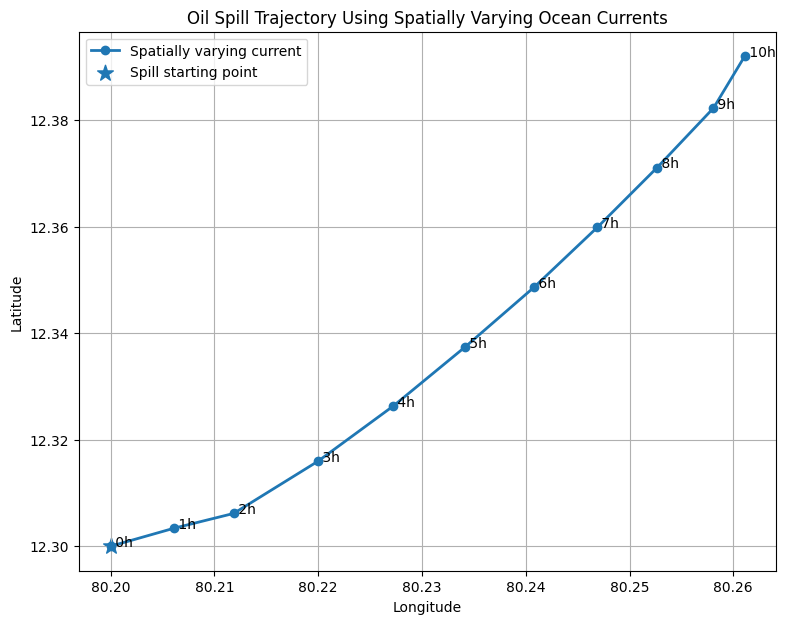

In [ ]:
# ============================================================
# SPATIALLY VARYING LAGRANGIAN TRAJECTORY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Starting spill location
spill_lat = 12.30
spill_lon = 80.20

# Start from the first available time
start_index = 0

# Simulate 10 hours
num_hours = 10

# Starting position
lat = spill_lat
lon = spill_lon

trajectory_lat = [lat]
trajectory_lon = [lon]
trajectory_time = [ds.time.isel(time=start_index).values]

print("Starting position:")
print(f"Latitude : {lat}")
print(f"Longitude: {lon}")
print(f"Time     : {trajectory_time[0]}")

# ============================================================
# LAGRANGIAN PARTICLE TRACKING
# ============================================================

for i in range(num_hours):

    current_time_index = start_index + i

    # Find the nearest grid point to the CURRENT oil position
    lat_index = abs(ds.latitude - lat).argmin()
    lon_index = abs(ds.longitude - lon).argmin()

    grid_lat = float(ds.latitude.isel(latitude=lat_index))
    grid_lon = float(ds.longitude.isel(longitude=lon_index))

    # Extract REAL ocean current at current position and time
    u = float(
        uo.isel(
            time=current_time_index,
            latitude=lat_index,
            longitude=lon_index
        ).values
    )

    v = float(
        vo.isel(
            time=current_time_index,
            latitude=lat_index,
            longitude=lon_index
        ).values
    )

    # Check for missing data
    if np.isnan(u) or np.isnan(v):

        print(
            f"Hour {i}: Missing current data "
            f"at {grid_lat:.4f}, {grid_lon:.4f}"
        )

        break

    # One-hour timestep
    dt = 3600

    # Movement in metres
    east_distance = u * dt
    north_distance = v * dt

    # Convert metres to degrees
    lat = lat + north_distance / 111320.0

    lon = lon + (
        east_distance /
        (111320.0 * np.cos(np.radians(lat)))
    )

    # Save trajectory
    trajectory_lat.append(lat)
    trajectory_lon.append(lon)

    if current_time_index + 1 < len(ds.time):
        trajectory_time.append(
            ds.time.isel(
                time=current_time_index + 1
            ).values
        )

    print(
        f"Hour {i+1:2d} | "
        f"Grid: ({grid_lat:.4f}, {grid_lon:.4f}) | "
        f"u={u:.4f} m/s | "
        f"v={v:.4f} m/s | "
        f"Position=({lat:.5f}, {lon:.5f})"
    )


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 7))

plt.plot(
    trajectory_lon,
    trajectory_lat,
    marker="o",
    linewidth=2,
    label="Spatially varying current"
)

# Starting point
plt.scatter(
    trajectory_lon[0],
    trajectory_lat[0],
    s=140,
    marker="*",
    label="Spill starting point"
)

# Label hours
for i in range(len(trajectory_lat)):
    plt.text(
        trajectory_lon[i],
        trajectory_lat[i],
        f" {i}h"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Oil Spill Trajectory Using Spatially Varying Ocean Currents"
)

plt.grid(True)
plt.legend()

plt.show()

Reached beginning of available dataset.


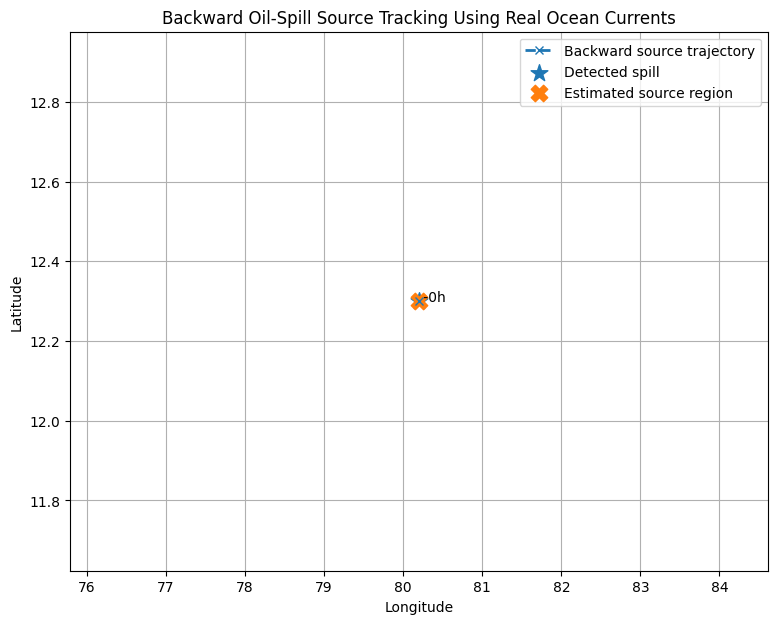

In [ ]:
# ============================================================
# BACKWARD OIL-SPILL SOURCE TRACKING
# Using REAL ocean-current data (uo, vo)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. DETECTED SPILL LOCATION
# ------------------------------------------------------------

spill_lat = 12.30
spill_lon = 80.20

# Spill detected at the first available time
spill_time_index = 0

# Number of hours to track backwards
backward_hours = 10

# Start at detected spill
lat = spill_lat
lon = spill_lon

back_lat = [lat]
back_lon = [lon]
back_time = [ds.time.isel(time=spill_time_index).values]


# ------------------------------------------------------------
# 2. BACKWARD TRACKING
# ------------------------------------------------------------

for i in range(backward_hours):

    # We need an earlier time.
    current_time_index = spill_time_index - i

    # Stop if we reach the beginning of the dataset
    if current_time_index <= 0:
        print("Reached beginning of available dataset.")
        break

    # Find the nearest current grid point
    lat_index = abs(ds.latitude - lat).argmin()
    lon_index = abs(ds.longitude - lon).argmin()

    grid_lat = float(ds.latitude.isel(latitude=lat_index))
    grid_lon = float(ds.longitude.isel(longitude=lon_index))

    # Extract REAL ocean currents
    u = float(
        uo.isel(
            time=current_time_index,
            latitude=lat_index,
            longitude=lon_index
        ).values
    )

    v = float(
        vo.isel(
            time=current_time_index,
            latitude=lat_index,
            longitude=lon_index
        ).values
    )

    # Check missing data
    if np.isnan(u) or np.isnan(v):

        print(
            f"Missing current data at "
            f"{grid_lat:.4f}, {grid_lon:.4f}"
        )
        break

    # One hour
    dt = 3600

    # Forward movement would be:
    #
    # east  = u * dt
    # north = v * dt
    #
    # For BACKWARD tracking we reverse the movement.

    east_distance = -u * dt
    north_distance = -v * dt

    # Convert metres → degrees

    lat = lat + north_distance / 111320.0

    lon = lon + (
        east_distance /
        (111320.0 * np.cos(np.radians(lat)))
    )

    # Save position
    back_lat.append(lat)
    back_lon.append(lon)

    # Save previous time
    back_time.append(
        ds.time.isel(
            time=current_time_index - 1
        ).values
    )

    print(
        f"Backward {i+1:2d}h | "
        f"u={u:.4f} m/s | "
        f"v={v:.4f} m/s | "
        f"Position=({lat:.5f}, {lon:.5f})"
    )


# ------------------------------------------------------------
# 3. PLOT BACKWARD SOURCE TRAJECTORY
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.plot(
    back_lon,
    back_lat,
    marker="x",
    linestyle="--",
    linewidth=2,
    label="Backward source trajectory"
)

# Detected spill
plt.scatter(
    spill_lon,
    spill_lat,
    s=160,
    marker="*",
    label="Detected spill"
)

# Estimated source
plt.scatter(
    back_lon[-1],
    back_lat[-1],
    s=140,
    marker="X",
    label="Estimated source region"
)

# Time labels
for i in range(len(back_lat)):
    plt.text(
        back_lon[i],
        back_lat[i],
        f" -{i}h"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Backward Oil-Spill Source Tracking Using Real Ocean Currents"
)

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Check the current at the chosen spill time and location

spill_lat = 12.30
spill_lon = 80.20
spill_time_index = 10

lat_index = abs(ds.latitude - spill_lat).argmin()
lon_index = abs(ds.longitude - spill_lon).argmin()

print("Nearest grid point:")
print("Latitude :", float(ds.latitude.isel(latitude=lat_index)))
print("Longitude:", float(ds.longitude.isel(longitude=lon_index)))

print("\nSpill time:")
print(ds.time.isel(time=spill_time_index).values)

u_test = uo.isel(
    time=spill_time_index,
    latitude=lat_index,
    longitude=lon_index
).values

v_test = vo.isel(
    time=spill_time_index,
    latitude=lat_index,
    longitude=lon_index
).values

print("\nu =", u_test)
print("v =", v_test)

Nearest grid point:
Latitude : 12.333333015441895
Longitude: 80.16666412353516

Spill time:
2026-09-08T16:00:00.000000000

u = 0.08203125
v = 0.16113281


In [ ]:
print("Previous/current values at the spill grid point:\n")

for i in range(10, -1, -1):

    u_val = uo.isel(
        time=i,
        latitude=lat_index,
        longitude=lon_index
    ).values

    v_val = vo.isel(
        time=i,
        latitude=lat_index,
        longitude=lon_index
    ).values

    print(
        i,
        ds.time.isel(time=i).values,
        "u =", u_val,
        "v =", v_val
    )

Previous/current values at the spill grid point:

10 2026-09-08T16:00:00.000000000 u = 0.08203125 v = 0.16113281
9 2026-09-08T15:00:00.000000000 u = 0.078125 v = 0.15527344
8 2026-09-08T14:00:00.000000000 u = 0.080078125 v = 0.15332031
7 2026-09-08T13:00:00.000000000 u = 0.0859375 v = 0.14746094
6 2026-09-08T12:00:00.000000000 u = 0.09375 v = 0.140625
5 2026-09-08T11:00:00.000000000 u = 0.10058594 v = 0.14160156
4 2026-09-08T10:00:00.000000000 u = 0.10546875 v = 0.12988281
3 2026-09-08T09:00:00.000000000 u = 0.119140625 v = 0.1015625
2 2026-09-08T08:00:00.000000000 u = 0.14941406 v = 0.08203125
1 2026-09-08T07:00:00.000000000 u = 0.17382812 v = 0.0859375
0 2026-09-08T06:00:00.000000000 u = 0.18457031 v = 0.10449219


 -1 h | time=2026-09-08T15:00:00.000000000 | u=0.0781 | v=0.1553 | lat=12.29498 | lon=80.19741
 -2 h | time=2026-09-08T14:00:00.000000000 | u=0.0801 | v=0.1533 | lat=12.29002 | lon=80.19476
 -3 h | time=2026-09-08T13:00:00.000000000 | u=0.1777 | v=0.2734 | lat=12.28118 | lon=80.18888
 -4 h | time=2026-09-08T12:00:00.000000000 | u=0.1914 | v=0.2754 | lat=12.27227 | lon=80.18255
 -5 h | time=2026-09-08T11:00:00.000000000 | u=0.2051 | v=0.2793 | lat=12.26324 | lon=80.17576
 -6 h | time=2026-09-08T10:00:00.000000000 | u=0.2197 | v=0.2812 | lat=12.25414 | lon=80.16849
 -7 h | time=2026-09-08T09:00:00.000000000 | u=0.2295 | v=0.2715 | lat=12.24536 | lon=80.16089
 -8 h | time=2026-09-08T08:00:00.000000000 | u=0.2520 | v=0.2510 | lat=12.23725 | lon=80.15256
 -9 h | time=2026-09-08T07:00:00.000000000 | u=0.2734 | v=0.2451 | lat=12.22932 | lon=80.14351
-10 h | time=2026-09-08T06:00:00.000000000 | u=0.2812 | v=0.2646 | lat=12.22076 | lon=80.13420


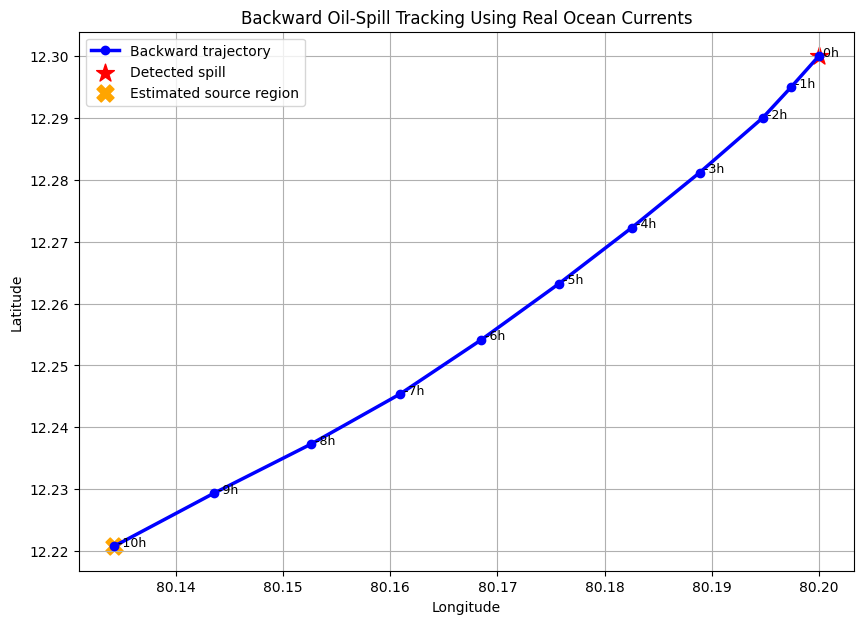

In [ ]:
# ============================================================
# BACKWARD LAGRANGIAN TRACKING
# Real ocean-current data
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SPILL INFORMATION
# ------------------------------------------------------------

spill_lat = 12.30
spill_lon = 80.20

# Spill detected at 16:00
spill_time_index = 10

# Number of hours to go backwards
backward_hours = 10

# Starting position
lat = spill_lat
lon = spill_lon

back_lat = [lat]
back_lon = [lon]
back_hours = [0]

# ------------------------------------------------------------
# BACKWARD TRACKING
# ------------------------------------------------------------

for step in range(1, backward_hours + 1):

    # Go one hour earlier each step
    time_index = spill_time_index - step

    if time_index < 0:
        break

    # Find nearest grid point to CURRENT particle position
    lat_index = abs(ds.latitude - lat).argmin()
    lon_index = abs(ds.longitude - lon).argmin()

    # Get real ocean current
    u = float(
        uo.isel(
            time=time_index,
            latitude=lat_index,
            longitude=lon_index
        ).values
    )

    v = float(
        vo.isel(
            time=time_index,
            latitude=lat_index,
            longitude=lon_index
        ).values
    )

    # Check for missing values
    if np.isnan(u) or np.isnan(v):
        print("Missing current encountered.")
        break

    # One hour
    dt = 3600

    # BACKWARD movement
    east_distance = -u * dt
    north_distance = -v * dt

    # Convert metres to degrees
    lat = lat + north_distance / 111320

    lon = lon + (
        east_distance /
        (111320 * np.cos(np.radians(lat)))
    )

    # Save
    back_lat.append(lat)
    back_lon.append(lon)
    back_hours.append(-step)

    print(
        f"{-step:3d} h | "
        f"time={ds.time.isel(time=time_index).values} | "
        f"u={u:.4f} | "
        f"v={v:.4f} | "
        f"lat={lat:.5f} | "
        f"lon={lon:.5f}"
    )


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.plot(
    back_lon,
    back_lat,
    marker="o",
    linewidth=2.5,
    color="blue",
    label="Backward trajectory"
)

# Detected spill
plt.scatter(
    spill_lon,
    spill_lat,
    s=180,
    marker="*",
    color="red",
    label="Detected spill"
)

# Estimated source
plt.scatter(
    back_lon[-1],
    back_lat[-1],
    s=150,
    marker="X",
    color="orange",
    label="Estimated source region"
)

# Label each point
for i in range(len(back_lat)):
    plt.text(
        back_lon[i],
        back_lat[i],
        f" {back_hours[i]}h",
        fontsize=9
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Backward Oil-Spill Tracking Using Real Ocean Currents"
)

plt.grid(True)
plt.legend()

plt.show()

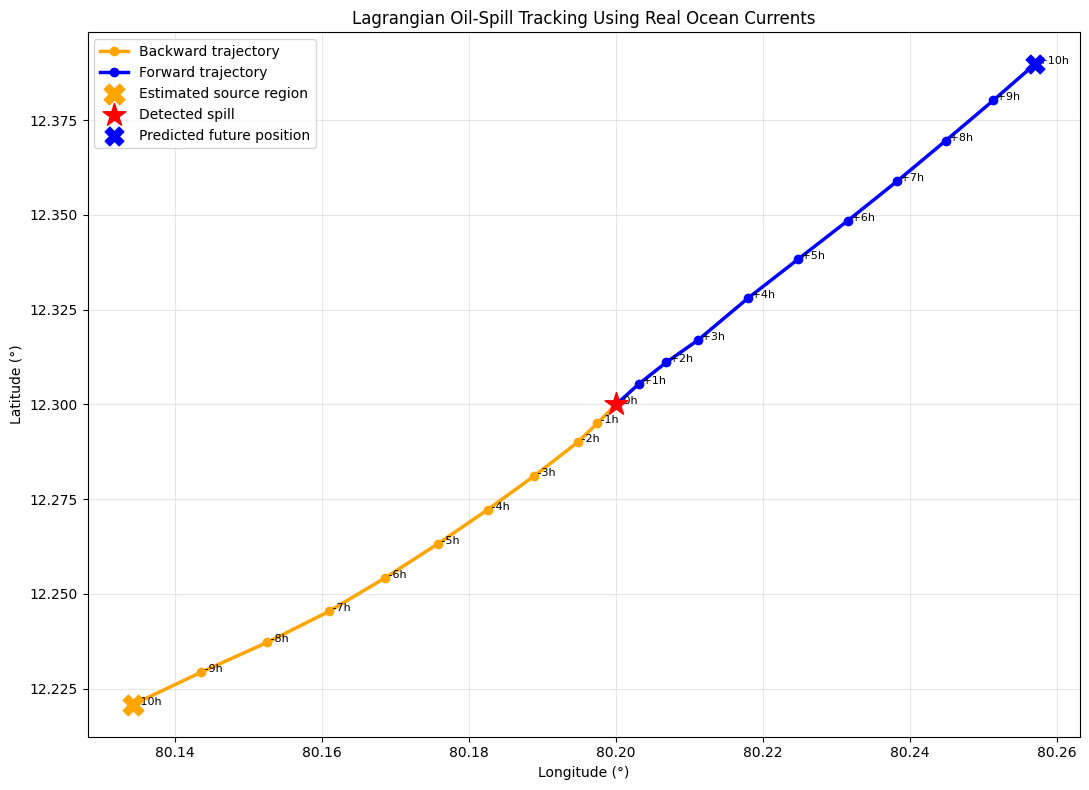

In [ ]:
# ============================================================
# COMBINED BACKWARD + FORWARD LAGRANGIAN TRAJECTORY
# Real ocean-current data
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. SPILL INFORMATION
# ------------------------------------------------------------

spill_lat = 12.30
spill_lon = 80.20

spill_time_index = 10

# ============================================================
# 2. BACKWARD TRAJECTORY
# ============================================================

backward_hours = 10

lat = spill_lat
lon = spill_lon

back_lat = [lat]
back_lon = [lon]

for step in range(1, backward_hours + 1):

    time_index = spill_time_index - step

    if time_index < 0:
        break

    lat_index = abs(ds.latitude - lat).argmin()
    lon_index = abs(ds.longitude - lon).argmin()

    u = float(
        uo.isel(
            time=time_index,
            latitude=lat_index,
            longitude=lon_index
        ).values
    )

    v = float(
        vo.isel(
            time=time_index,
            latitude=lat_index,
            longitude=lon_index
        ).values
    )

    if np.isnan(u) or np.isnan(v):
        break

    dt = 3600

    # Backward movement
    lat -= (v * dt) / 111320

    lon -= (
        u * dt /
        (111320 * np.cos(np.radians(lat)))
    )

    back_lat.append(lat)
    back_lon.append(lon)


# ============================================================
# 3. FORWARD TRAJECTORY
# ============================================================

forward_hours = 10

lat = spill_lat
lon = spill_lon

forward_lat = [lat]
forward_lon = [lon]

for step in range(1, forward_hours + 1):

    time_index = spill_time_index + step

    if time_index >= len(ds.time):
        break

    lat_index = abs(ds.latitude - lat).argmin()
    lon_index = abs(ds.longitude - lon).argmin()

    u = float(
        uo.isel(
            time=time_index,
            latitude=lat_index,
            longitude=lon_index
        ).values
    )

    v = float(
        vo.isel(
            time=time_index,
            latitude=lat_index,
            longitude=lon_index
        ).values
    )

    if np.isnan(u) or np.isnan(v):
        break

    dt = 3600

    # Forward movement
    lat += (v * dt) / 111320

    lon += (
        u * dt /
        (111320 * np.cos(np.radians(lat)))
    )

    forward_lat.append(lat)
    forward_lon.append(lon)


# ============================================================
# 4. FINAL COMBINED GRAPH
# ============================================================

plt.figure(figsize=(11, 8))

# BACKWARD
plt.plot(
    back_lon,
    back_lat,
    color="orange",
    marker="o",
    linewidth=2.5,
    label="Backward trajectory"
)

# FORWARD
plt.plot(
    forward_lon,
    forward_lat,
    color="blue",
    marker="o",
    linewidth=2.5,
    label="Forward trajectory"
)

# ESTIMATED SOURCE
plt.scatter(
    back_lon[-1],
    back_lat[-1],
    color="orange",
    marker="X",
    s=220,
    zorder=5,
    label="Estimated source region"
)

# DETECTED SPILL
plt.scatter(
    spill_lon,
    spill_lat,
    color="red",
    marker="*",
    s=300,
    zorder=6,
    label="Detected spill"
)

# FUTURE END
plt.scatter(
    forward_lon[-1],
    forward_lat[-1],
    color="blue",
    marker="X",
    s=180,
    zorder=5,
    label="Predicted future position"
)

# ------------------------------------------------------------
# 5. LABEL BACKWARD TIMES
# ------------------------------------------------------------

for i in range(len(back_lat)):
    plt.text(
        back_lon[i],
        back_lat[i],
        f" -{i}h",
        fontsize=8
    )

# ------------------------------------------------------------
# 6. LABEL FORWARD TIMES
# ------------------------------------------------------------

for i in range(1, len(forward_lat)):
    plt.text(
        forward_lon[i],
        forward_lat[i],
        f" +{i}h",
        fontsize=8
    )

# ------------------------------------------------------------
# 7. GRAPH DETAILS
# ------------------------------------------------------------

plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")

plt.title(
    "Lagrangian Oil-Spill Tracking Using Real Ocean Currents"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()